# Exploratory analysis — HSSE incidents SQLite

This separate, read-only notebook profiles
`data/processed/hsse_incidents.sqlite`. It focuses on corpus composition,
label coverage, source effects, dates, countries, text length, model splits,
and full-text search. All headline values are calculated from the database at
execution time rather than copied into notebook prose.

## Analytical framing

The database is a deliberately balanced research corpus, not a prevalence
sample. Each case type has an equal quota, and each type is tied to a specific
authentic source or documented source rule. Comparisons across labels therefore
describe this dataset—not population incident rates. Several labels and severity
values are deterministic weak labels and require human validation before being
treated as ground truth.

In [1]:
from __future__ import annotations

import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "blue": "#4472C4",
    "gold": "#D6A21E",
    "orange": "#ED7D31",
    "olive": "#708238",
    "pink": "#C85A7C",
    "ink": "#263238",
    "light_blue": "#B9CBE8",
}
plt.rcParams.update({
    "axes.titleweight": "bold",
    "axes.edgecolor": "#455A64",
    "axes.labelcolor": COLORS["ink"],
    "text.color": COLORS["ink"],
    "figure.dpi": 110,
})
pd.set_option("display.max_colwidth", 140)
count_formatter = FuncFormatter(lambda value, _: f"{value:,.0f}")


def locate_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "incident_pipeline").is_dir() and (
            candidate / "config" / "pipeline.json"
        ).is_file():
            return candidate
    raise FileNotFoundError("Could not locate the project root")


PROJECT_ROOT = locate_project_root(Path.cwd().resolve())
DB_PATH = Path(
    os.environ.get(
        "HSSE_DATABASE_PATH",
        str(
            PROJECT_ROOT
            / "data"
            / "processed"
            / "hsse_incidents.sqlite"
        ),
    )
).resolve()
connection = sqlite3.connect(f"file:{DB_PATH.as_posix()}?mode=ro", uri=True)
print(f"Read-only database: {DB_PATH}")

Read-only database: /Users/shariarimrozekhan/Documents/hsse-chatbot-implement/data/processed/hsse_incidents.sqlite


## 1. Database structure and integrity

In [2]:
objects = pd.read_sql_query(
    '''
    SELECT type, name
    FROM sqlite_master
    WHERE name NOT LIKE 'sqlite_%'
    ORDER BY type, name
    ''',
    connection,
)
schema = pd.read_sql_query("PRAGMA table_info(incidents)", connection)
display(objects)
display(schema[["cid", "name", "type", "notnull", "pk"]])
quick_check = connection.execute("PRAGMA quick_check").fetchone()[0]
print("SQLite quick_check:", quick_check)
assert quick_check == "ok"

,type,name
0,index,idx_incidents_actual_severity
1,index,idx_incidents_case_type
2,index,idx_incidents_country
3,index,idx_incidents_dataset_split
4,index,idx_incidents_hazard_type
5,index,idx_incidents_potential_severity
6,index,idx_incidents_source
7,table,incidents
8,table,incidents_fts
9,table,incidents_fts_config


,cid,name,type,notnull,pk
0,0,case_no,TEXT,0,1
1,1,country,TEXT,1,0
2,2,title,TEXT,1,0
3,3,description,TEXT,1,0
4,4,case_type,TEXT,1,0
5,5,hazard,TEXT,1,0
6,6,hazard_type,TEXT,1,0
7,7,actual_severity,TEXT,1,0
8,8,potential_severity,TEXT,1,0
9,9,source,TEXT,1,0


SQLite quick_check: ok


In [3]:
integrity = pd.read_sql_query(
    '''
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT case_no) AS distinct_case_no,
        COUNT(DISTINCT text_hash) AS distinct_text_hash,
        COUNT(DISTINCT source || char(31) || source_record_id)
            AS distinct_source_record,
        SUM(TRIM(description) = '') AS blank_description,
        SUM(TRIM(country) = '') AS blank_country,
        SUM(TRIM(event_date) = '') AS blank_event_date
    FROM incidents
    ''',
    connection,
)
fts_rows = connection.execute("SELECT COUNT(*) FROM incidents_fts").fetchone()[0]
integrity["fts_rows"] = fts_rows
display(integrity.T.rename(columns={0: "value"}))
assert integrity.loc[0, "rows"] == 400_000
assert integrity.loc[0, "rows"] == integrity.loc[0, "distinct_case_no"]
assert integrity.loc[0, "rows"] == integrity.loc[0, "distinct_text_hash"]
assert integrity.loc[0, "rows"] == integrity.loc[0, "distinct_source_record"]
assert fts_rows == integrity.loc[0, "rows"]

,value
rows,400000
distinct_case_no,400000
distinct_text_hash,400000
distinct_source_record,400000
blank_description,0
blank_country,0
blank_event_date,0
fts_rows,400000


## 2. Case-type balance and source dependence

,case_type,records,share_pct
0,Asset and Reputation Damage/Loss,50000,12.5
1,Environment,50000,12.5
2,Information Security,50000,12.5
3,Occupational Health,50000,12.5
4,Occupational Safety,50000,12.5
5,Operational Loss,50000,12.5
6,Physical Security,50000,12.5
7,Process Safety,50000,12.5


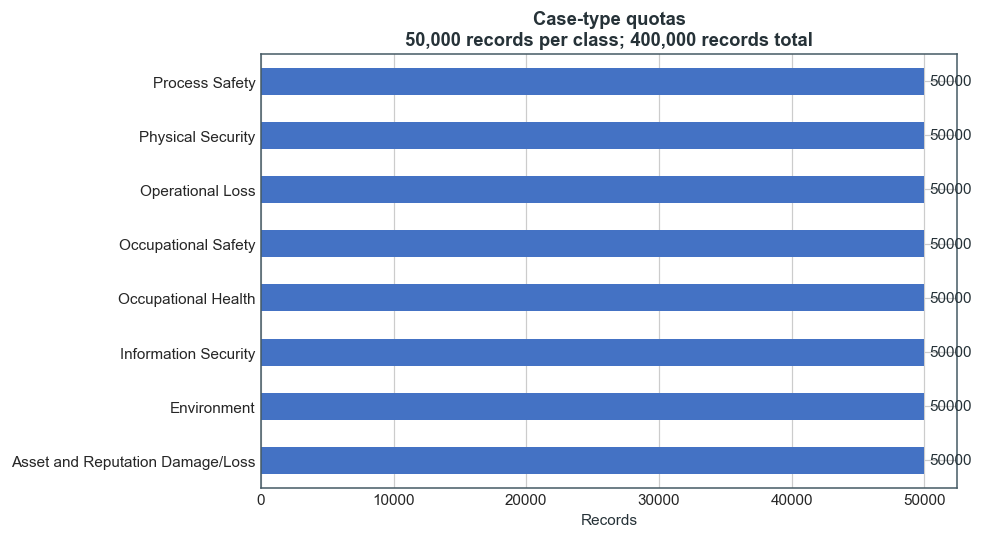

In [4]:
case_counts = pd.read_sql_query(
    '''
    SELECT case_type, COUNT(*) AS records
    FROM incidents
    GROUP BY case_type
    ORDER BY records DESC, case_type
    ''',
    connection,
)
case_counts["share_pct"] = 100 * case_counts["records"] / case_counts["records"].sum()
display(case_counts)
assert len(case_counts) == 8
assert set(case_counts["records"]) == {50_000}
assert case_counts["records"].sum() == 400_000

ax = case_counts.sort_values("records").plot.barh(
    x="case_type", y="records", legend=False, figsize=(9, 5), color="#4472C4"
)
ax.set(
    xlabel="Records", ylabel="",
    title="Case-type quotas\n50,000 records per class; 400,000 records total",
)
ax.bar_label(ax.containers[0], fmt="%d", padding=3)
plt.tight_layout()
plt.show()

case_type,Asset and Reputation Damage/Loss,Environment,Information Security,Occupational Health,Occupational Safety,Operational Loss,Physical Security,Process Safety
source,,,,,,,,
CALOES_SPILL,0.0,50000.0,0.0,0.0,0.0,0.0,0.0,0.0
CFPB_CONSUMER_COMPLAINT,0.0,0.0,50000.0,0.0,0.0,0.0,0.0,0.0
FAA_SDR,50000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
FDA_RES,0.0,0.0,0.0,0.0,0.0,50000.0,0.0,0.0
OSHA_ITA_CASE_DETAIL,0.0,0.0,0.0,50000.0,50000.0,0.0,0.0,0.0
POLICE_UK,0.0,0.0,0.0,0.0,0.0,0.0,50000.0,0.0
USCG_NRC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50000.0


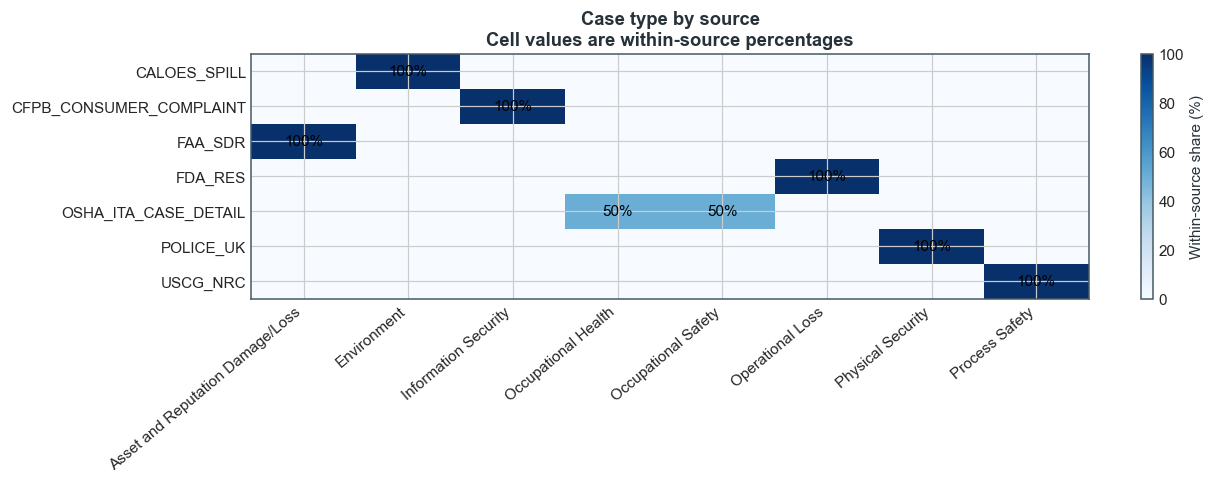

In [5]:
source_case = pd.read_sql_query(
    '''
    SELECT source, case_type, COUNT(*) AS records
    FROM incidents
    GROUP BY source, case_type
    ''',
    connection,
)
source_case_pivot = source_case.pivot_table(
    index="source", columns="case_type", values="records", fill_value=0
)
source_case_pct = source_case_pivot.div(source_case_pivot.sum(axis=1), axis=0) * 100
display(source_case_pivot)

fig, ax = plt.subplots(figsize=(12, 4.5))
image = ax.imshow(source_case_pct, aspect="auto", cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(len(source_case_pct.columns)), source_case_pct.columns, rotation=40, ha="right")
ax.set_yticks(range(len(source_case_pct.index)), source_case_pct.index)
for i in range(source_case_pct.shape[0]):
    for j in range(source_case_pct.shape[1]):
        value = source_case_pct.iloc[i, j]
        if value:
            ax.text(j, i, f"{value:.0f}%", ha="center", va="center", color="black")
fig.colorbar(image, ax=ax, label="Within-source share (%)")
ax.set_title("Case type by source\nCell values are within-source percentages")
plt.tight_layout()
plt.show()

## 3. Hazard and severity labels

,hazard_type,records,share_pct
0,Loss of Containment/Release,62064,15.51600
1,Physical Security,51621,12.90525
2,Asset Damage/Loss,50000,12.50000
3,Cyber—Identity Theft/Fraud,50000,12.50000
4,Operational Disruption/Loss,50000,12.50000
5,Environmental Pollution,26222,6.55550
6,Ergonomic/Manual Handling,25604,6.40100
7,Other/Unknown,18336,4.58400
8,Machinery/Caught-In/Struck-By,13099,3.27475
9,Biological/Health,12547,3.13675


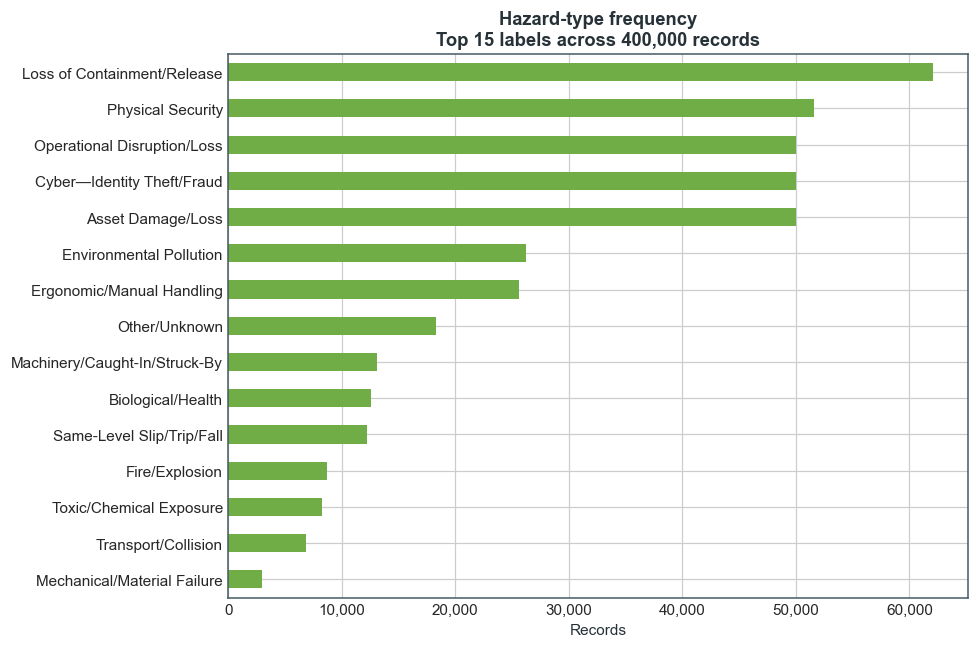

case_type,Asset and Reputation Damage/Loss,Environment,Information Security,Occupational Health,Occupational Safety,Operational Loss,Physical Security,Process Safety
hazard_type,,,,,,,,
Loss of Containment/Release,0.0,46.96,0.0,1.08,1.29,0.0,0.0,74.80
Physical Security,0.0,0.00,0.0,1.26,1.95,0.0,100.0,0.04
Operational Disruption/Loss,0.0,0.00,0.0,0.00,0.00,100.0,0.0,0.00
Asset Damage/Loss,100.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00
Cyber—Identity Theft/Fraud,0.0,0.00,100.0,0.00,0.00,0.0,0.0,0.00
Environmental Pollution,0.0,45.70,0.0,0.11,0.03,0.0,0.0,6.60
Ergonomic/Manual Handling,0.0,0.00,0.0,21.95,29.24,0.0,0.0,0.02
Other/Unknown,0.0,0.00,0.0,27.69,8.98,0.0,0.0,0.00
Machinery/Caught-In/Struck-By,0.0,0.00,0.0,3.60,22.06,0.0,0.0,0.54


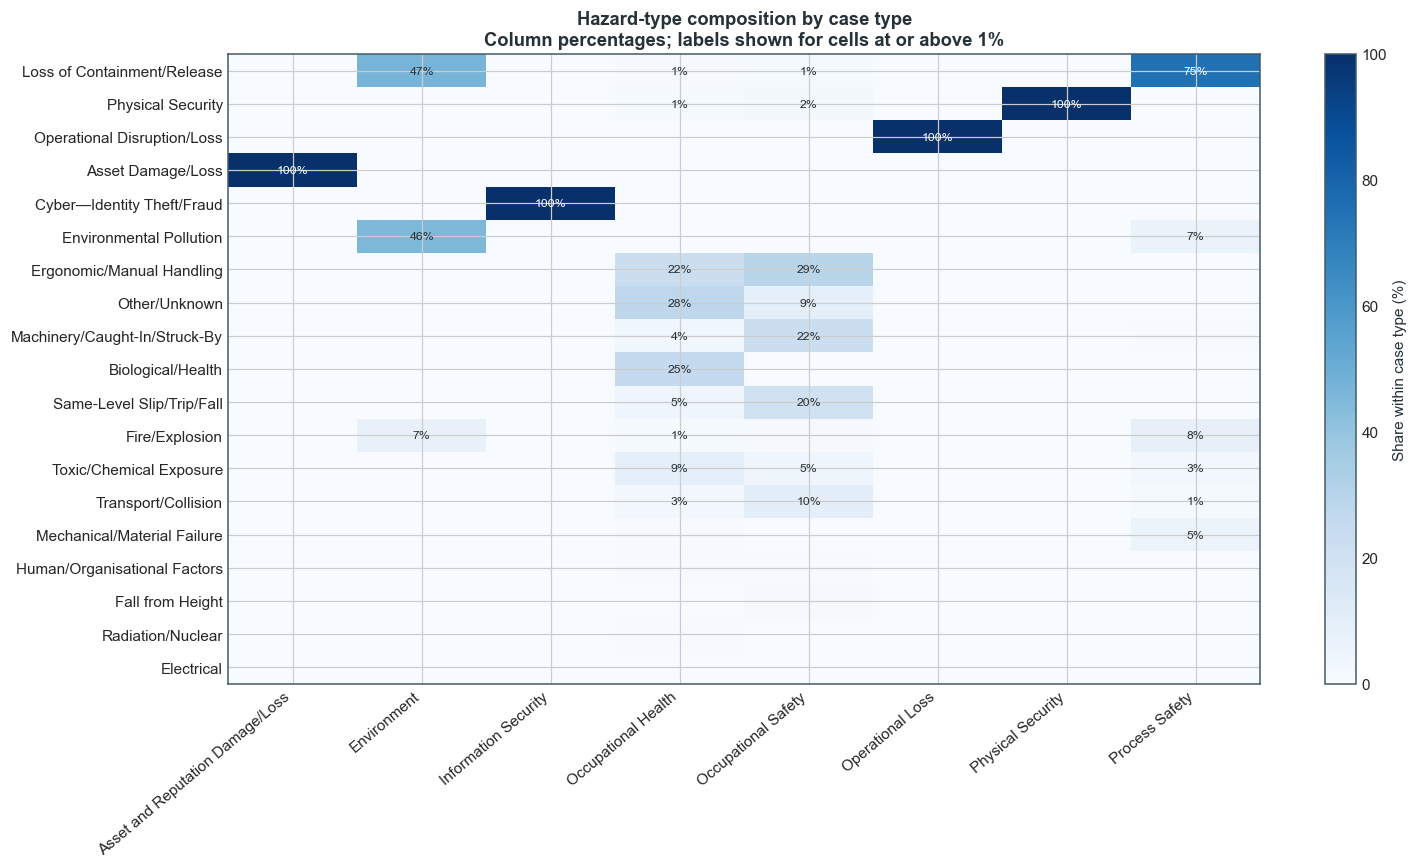

In [6]:
hazard_counts = pd.read_sql_query(
    '''
    SELECT hazard_type, COUNT(*) AS records
    FROM incidents
    GROUP BY hazard_type
    ORDER BY records DESC
    ''',
    connection,
)
hazard_counts["share_pct"] = 100 * hazard_counts["records"] / hazard_counts["records"].sum()
display(hazard_counts)

top_hazards = hazard_counts.head(15).sort_values("records")
ax = top_hazards.plot.barh(
    x="hazard_type", y="records", legend=False, figsize=(9, 6), color="#70AD47"
)
ax.set(
    xlabel="Records", ylabel="",
    title="Hazard-type frequency\nTop 15 labels across 400,000 records",
)
ax.xaxis.set_major_formatter(count_formatter)
plt.tight_layout()
plt.show()

hazard_case = pd.read_sql_query(
    '''
    SELECT case_type, hazard_type, COUNT(*) AS records
    FROM incidents
    GROUP BY case_type, hazard_type
    ''',
    connection,
)
hazard_case_pivot = hazard_case.pivot_table(
    index="hazard_type", columns="case_type", values="records", fill_value=0
)
hazard_case_pct = hazard_case_pivot.div(hazard_case_pivot.sum(axis=0), axis=1) * 100
hazard_order = hazard_case_pivot.sum(axis=1).sort_values(ascending=False).index
hazard_case_pct = hazard_case_pct.loc[hazard_order]
display(hazard_case_pct.round(2))

fig, ax = plt.subplots(figsize=(14, 8))
image = ax.imshow(hazard_case_pct, aspect="auto", cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(
    range(len(hazard_case_pct.columns)), hazard_case_pct.columns, rotation=40, ha="right"
)
ax.set_yticks(range(len(hazard_case_pct.index)), hazard_case_pct.index)
for row_index in range(hazard_case_pct.shape[0]):
    for column_index in range(hazard_case_pct.shape[1]):
        value = hazard_case_pct.iloc[row_index, column_index]
        if value >= 1:
            ax.text(
                column_index, row_index, f"{value:.0f}%",
                ha="center", va="center",
                color="white" if value >= 55 else COLORS["ink"], fontsize=8,
            )
fig.colorbar(image, ax=ax, label="Share within case type (%)")
ax.set(
    xlabel="", ylabel="",
    title="Hazard-type composition by case type\nColumn percentages; labels shown for cells at or above 1%",
)
plt.tight_layout()
plt.show()

potential_severity,Low,Medium,Severe,Unknown
actual_severity,,,,
Low,13888.0,41535.0,76170.0,0.0
Medium,0.0,82256.0,22668.0,0.0
Severe,0.0,0.0,10799.0,0.0
Unknown,0.0,663.0,2021.0,150000.0


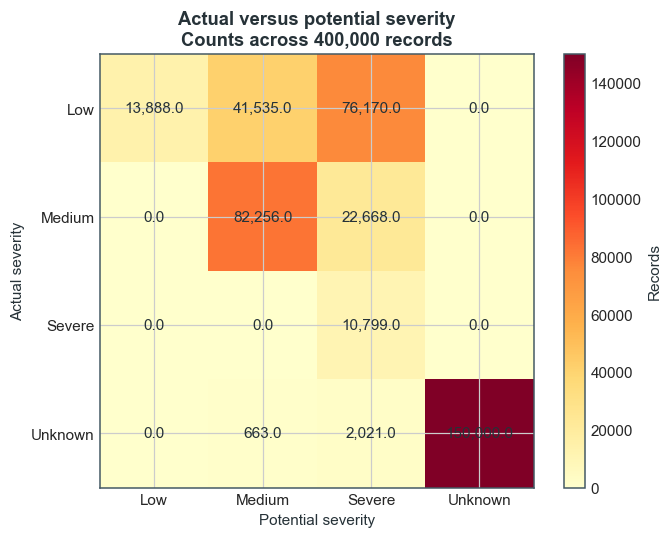

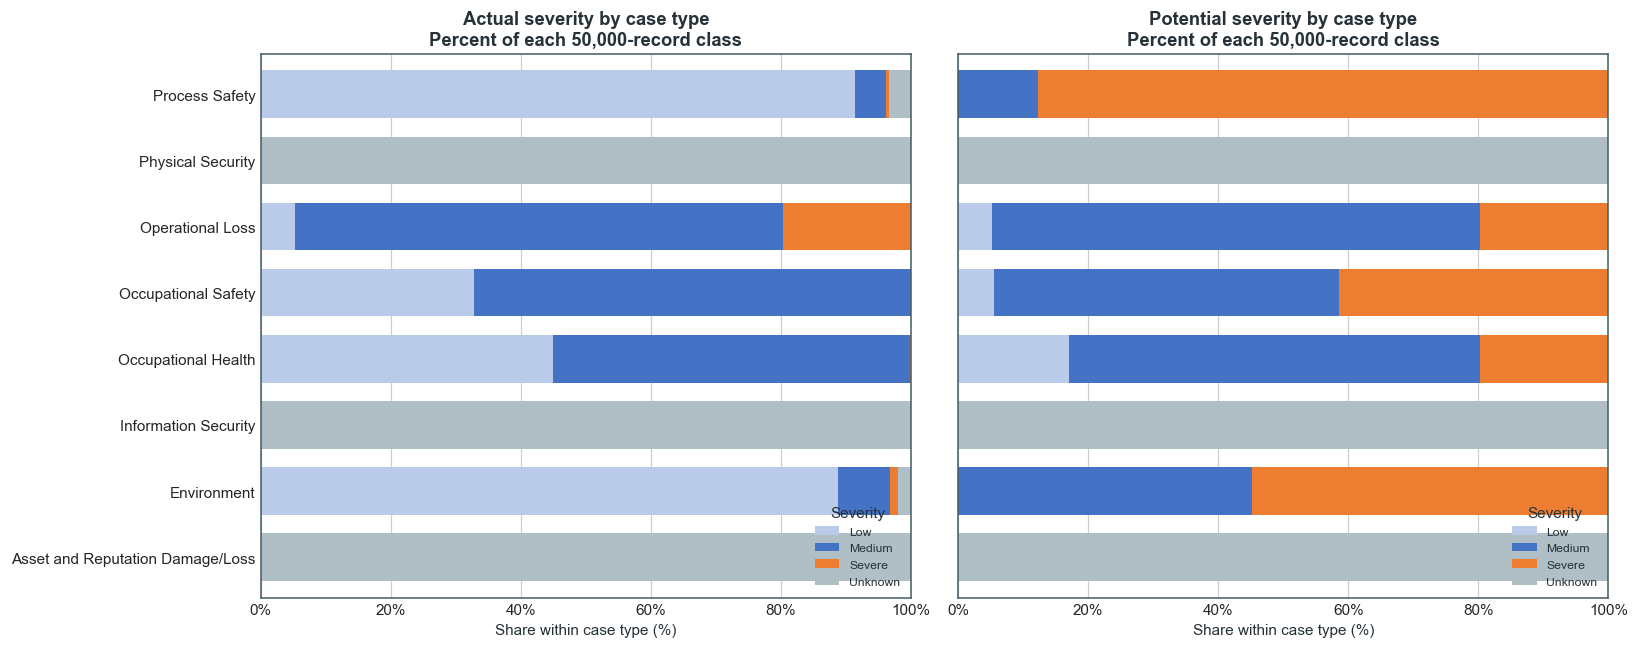

In [7]:
severity = pd.read_sql_query(
    '''
    SELECT actual_severity, potential_severity, COUNT(*) AS records
    FROM incidents
    GROUP BY actual_severity, potential_severity
    ''',
    connection,
)
severity_matrix = severity.pivot_table(
    index="actual_severity",
    columns="potential_severity",
    values="records",
    fill_value=0,
).reindex(index=["Low", "Medium", "Severe", "Unknown"],
          columns=["Low", "Medium", "Severe", "Unknown"], fill_value=0)
display(severity_matrix)

fig, ax = plt.subplots(figsize=(6.5, 5))
image = ax.imshow(severity_matrix, cmap="YlOrRd")
ax.set_xticks(range(4), severity_matrix.columns)
ax.set_yticks(range(4), severity_matrix.index)
ax.set(xlabel="Potential severity", ylabel="Actual severity",
       title="Actual versus potential severity\nCounts across 400,000 records")
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{severity_matrix.iloc[i, j]:,}", ha="center", va="center")
fig.colorbar(image, ax=ax, label="Records")
plt.tight_layout()
plt.show()

severity_by_case = pd.read_sql_query(
    '''
    SELECT case_type, actual_severity, potential_severity, COUNT(*) AS records
    FROM incidents
    GROUP BY case_type, actual_severity, potential_severity
    ''',
    connection,
)
severity_order = ["Low", "Medium", "Severe", "Unknown"]
severity_colors = [
    COLORS["light_blue"], COLORS["blue"], COLORS["orange"], "#B0BEC5"
]
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for axis, severity_field, label in [
    (axes[0], "actual_severity", "Actual severity"),
    (axes[1], "potential_severity", "Potential severity"),
]:
    grouped = (
        severity_by_case.groupby(["case_type", severity_field])["records"]
        .sum()
        .unstack(fill_value=0)
        .reindex(columns=severity_order, fill_value=0)
    )
    grouped_pct = grouped.div(grouped.sum(axis=1), axis=0) * 100
    grouped_pct.plot.barh(
        stacked=True, ax=axis, color=severity_colors, width=0.72
    )
    axis.set(
        xlabel="Share within case type (%)", ylabel="",
        title=f"{label} by case type\nPercent of each 50,000-record class",
    )
    axis.set_xlim(0, 100)
    axis.xaxis.set_major_formatter(PercentFormatter(xmax=100))
    axis.legend(title="Severity", loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 4. Geographic composition

,country,records,share_pct
0,United States of America,346990,86.74750
1,United Kingdom,50181,12.54525
2,Canada,574,0.14350
3,Germany,273,0.06825
4,Netherlands,201,0.05025
5,China,196,0.04900
6,Switzerland,188,0.04700
7,India,178,0.04450
8,France,142,0.03550
9,Israel,137,0.03425


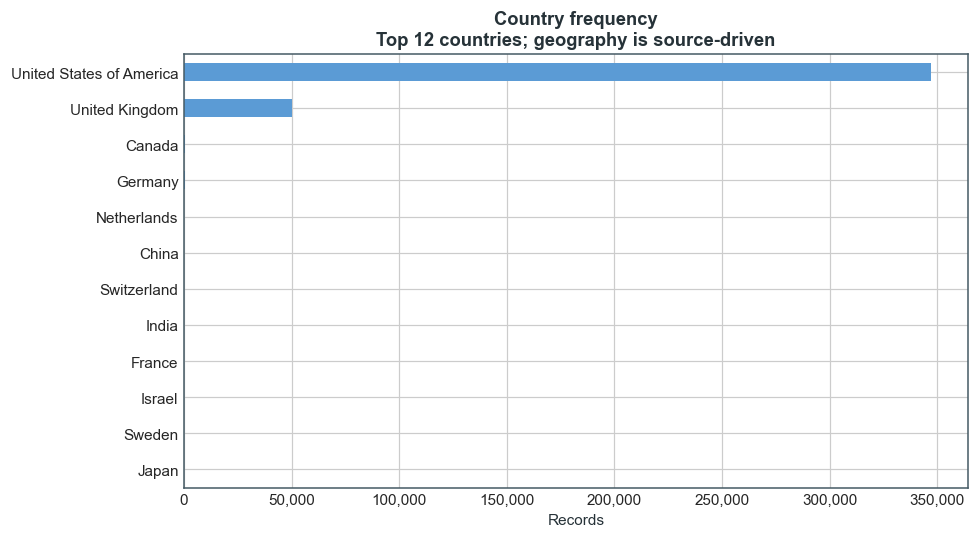

case_type,Asset and Reputation Damage/Loss,Environment,Information Security,Occupational Health,Occupational Safety,Operational Loss,Physical Security,Process Safety
country,,,,,,,,
United States of America,50000.0,50000.0,50000.0,50000.0,50000.0,46990.0,0.0,50000.0
United Kingdom,0.0,0.0,0.0,0.0,0.0,181.0,50000.0,0.0
Canada,0.0,0.0,0.0,0.0,0.0,574.0,0.0,0.0
Germany,0.0,0.0,0.0,0.0,0.0,273.0,0.0,0.0
Netherlands,0.0,0.0,0.0,0.0,0.0,201.0,0.0,0.0
China,0.0,0.0,0.0,0.0,0.0,196.0,0.0,0.0
Switzerland,0.0,0.0,0.0,0.0,0.0,188.0,0.0,0.0
India,0.0,0.0,0.0,0.0,0.0,178.0,0.0,0.0
France,0.0,0.0,0.0,0.0,0.0,142.0,0.0,0.0


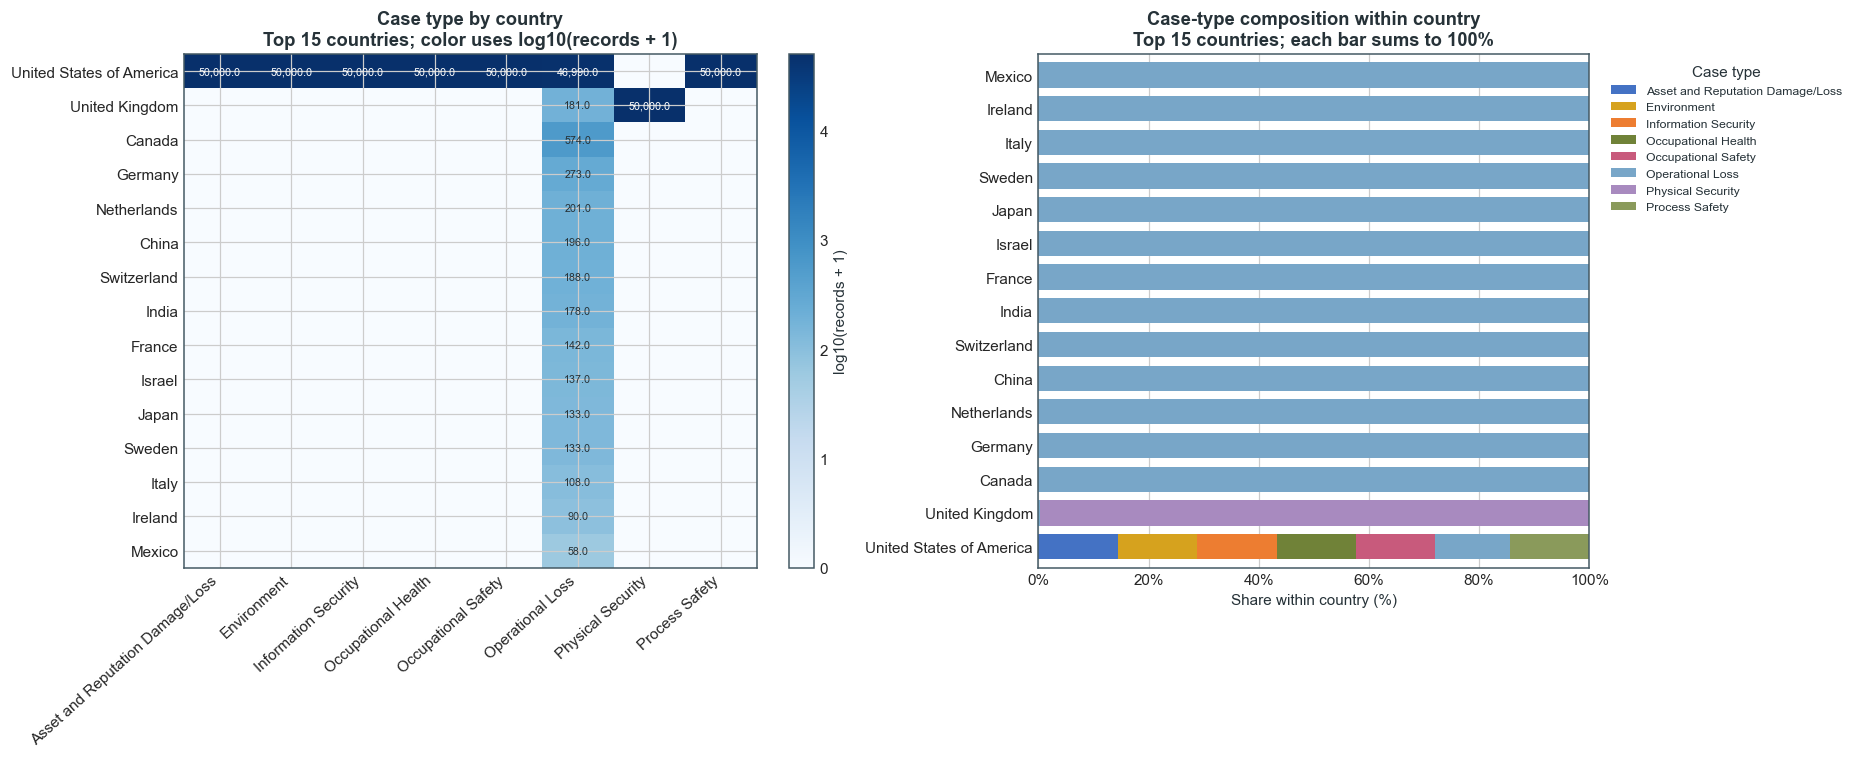

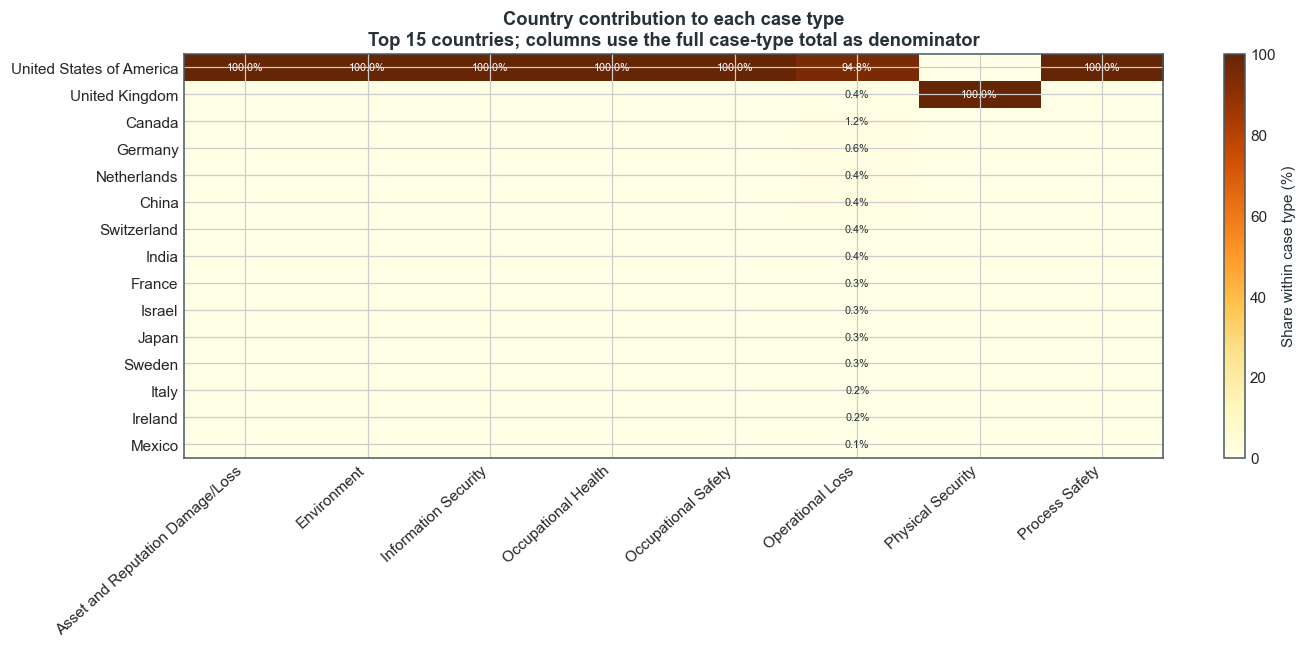

In [8]:
country_counts = pd.read_sql_query(
    '''
    SELECT country, COUNT(*) AS records
    FROM incidents
    GROUP BY country
    ORDER BY records DESC, country
    ''',
    connection,
)
country_counts["share_pct"] = 100 * country_counts["records"] / country_counts["records"].sum()
display(country_counts.head(20))

top_countries = country_counts.head(12).sort_values("records")
ax = top_countries.plot.barh(
    x="country", y="records", legend=False, figsize=(9, 5), color="#5B9BD5"
)
ax.set(
    xlabel="Records", ylabel="",
    title="Country frequency\nTop 12 countries; geography is source-driven",
)
ax.xaxis.set_major_formatter(count_formatter)
plt.tight_layout()
plt.show()

country_case = pd.read_sql_query(
    '''
    SELECT country, case_type, COUNT(*) AS records
    FROM incidents
    GROUP BY country, case_type
    ''',
    connection,
)
top_country_names = country_counts.head(15)["country"].tolist()
country_case_pivot = (
    country_case.pivot_table(
        index="country", columns="case_type", values="records", fill_value=0
    )
    .reindex(top_country_names)
)
display(country_case_pivot)

fig, axes = plt.subplots(1, 2, figsize=(17, 7), gridspec_kw={"width_ratios": [1.15, 1]})
log_country_case = np.log10(country_case_pivot + 1)
image = axes[0].imshow(log_country_case, aspect="auto", cmap="Blues")
axes[0].set_xticks(
    range(len(country_case_pivot.columns)),
    country_case_pivot.columns, rotation=42, ha="right",
)
axes[0].set_yticks(range(len(country_case_pivot.index)), country_case_pivot.index)
for row_index in range(country_case_pivot.shape[0]):
    for column_index in range(country_case_pivot.shape[1]):
        value = country_case_pivot.iloc[row_index, column_index]
        if value:
            axes[0].text(
                column_index, row_index, f"{value:,}",
                ha="center", va="center", fontsize=7,
                color="white" if value >= 5_000 else COLORS["ink"],
            )
fig.colorbar(image, ax=axes[0], label="log10(records + 1)", fraction=0.046)
axes[0].set(
    xlabel="", ylabel="",
    title="Case type by country\nTop 15 countries; color uses log10(records + 1)",
)

country_case_pct = country_case_pivot.div(country_case_pivot.sum(axis=1), axis=0) * 100
country_case_pct.plot.barh(
    stacked=True, ax=axes[1], width=0.75,
    color=["#4472C4", "#D6A21E", "#ED7D31", "#708238",
           "#C85A7C", "#78A6C8", "#A88ABF", "#8A9A5B"],
)
axes[1].set(
    xlabel="Share within country (%)", ylabel="",
    title="Case-type composition within country\nTop 15 countries; each bar sums to 100%",
)
axes[1].set_xlim(0, 100)
axes[1].xaxis.set_major_formatter(PercentFormatter(xmax=100))
axes[1].legend(title="Case type", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

case_country_pct = country_case_pivot.div(country_case_pivot.sum(axis=0), axis=1) * 100
fig, ax = plt.subplots(figsize=(13, 6))
image = ax.imshow(case_country_pct, aspect="auto", cmap="YlOrBr", vmin=0, vmax=100)
ax.set_xticks(
    range(len(case_country_pct.columns)), case_country_pct.columns, rotation=42, ha="right"
)
ax.set_yticks(range(len(case_country_pct.index)), case_country_pct.index)
for row_index in range(case_country_pct.shape[0]):
    for column_index in range(case_country_pct.shape[1]):
        value = case_country_pct.iloc[row_index, column_index]
        if value >= 0.1:
            ax.text(
                column_index, row_index, f"{value:.1f}%",
                ha="center", va="center", fontsize=7,
                color="white" if value >= 55 else COLORS["ink"],
            )
fig.colorbar(image, ax=ax, label="Share within case type (%)")
ax.set(
    xlabel="", ylabel="",
    title="Country contribution to each case type\nTop 15 countries; columns use the full case-type total as denominator",
)
plt.tight_layout()
plt.show()

## 5. Event-date coverage

Date formats differ by source. The parser below is source-aware and retains
Police.uk monthly precision rather than inventing an exact day for analysis.

In [9]:
dates = pd.read_sql_query("SELECT source, event_date FROM incidents", connection)
formats = {
    "CALOES_SPILL": "%Y-%m-%d",
    "FAA_SDR": "%m/%d/%Y",
    "FDA_RES": "%Y%m%d",
    "OSHA_ITA_CASE_DETAIL": "%Y-%m-%d",
    "POLICE_UK": "%Y-%m",
    "USCG_NRC": "%m/%d/%Y %H:%M",
}
parsed_parts = []
for source, group in dates.groupby("source", sort=False):
    values = group["event_date"]
    if source == "CFPB_CONSUMER_COMPLAINT":
        parsed = pd.to_datetime(values, errors="coerce", utc=True).dt.tz_localize(None)
    else:
        parsed = pd.to_datetime(values, format=formats[source], errors="coerce")
    part = group.copy()
    part["parsed_date"] = parsed
    part["date_precision"] = "month" if source == "POLICE_UK" else "day"
    parsed_parts.append(part)
parsed_dates = pd.concat(parsed_parts, ignore_index=True)
parsed_dates["year"] = parsed_dates["parsed_date"].dt.year.astype("Int64")

date_coverage = parsed_dates.groupby("source").agg(
    rows=("event_date", "size"),
    parsed=("parsed_date", "count"),
    minimum=("parsed_date", "min"),
    maximum=("parsed_date", "max"),
)
date_coverage["parse_rate_pct"] = 100 * date_coverage["parsed"] / date_coverage["rows"]
display(date_coverage)
assert date_coverage["parsed"].sum() == len(parsed_dates)
today = pd.Timestamp.now(tz="UTC").tz_localize(None).normalize()
assert not (parsed_dates["parsed_date"] > today).any()

,rows,parsed,minimum,maximum,parse_rate_pct
source,,,,,
CALOES_SPILL,50000,50000,1993-01-01 00:00:00,2024-12-30 00:00:00,100.0
CFPB_CONSUMER_COMPLAINT,50000,50000,2023-01-01 01:15:00,2025-07-01 23:53:27,100.0
FAA_SDR,50000,50000,2024-01-01 00:00:00,2025-12-31 00:00:00,100.0
FDA_RES,50000,50000,2005-07-01 00:00:00,2026-08-05 00:00:00,100.0
OSHA_ITA_CASE_DETAIL,100000,100000,2022-08-03 00:00:00,2025-12-31 00:00:00,100.0
POLICE_UK,50000,50000,2025-01-01 00:00:00,2025-03-01 00:00:00,100.0
USCG_NRC,50000,50000,1979-12-31 12:00:00,2024-12-30 22:30:00,100.0


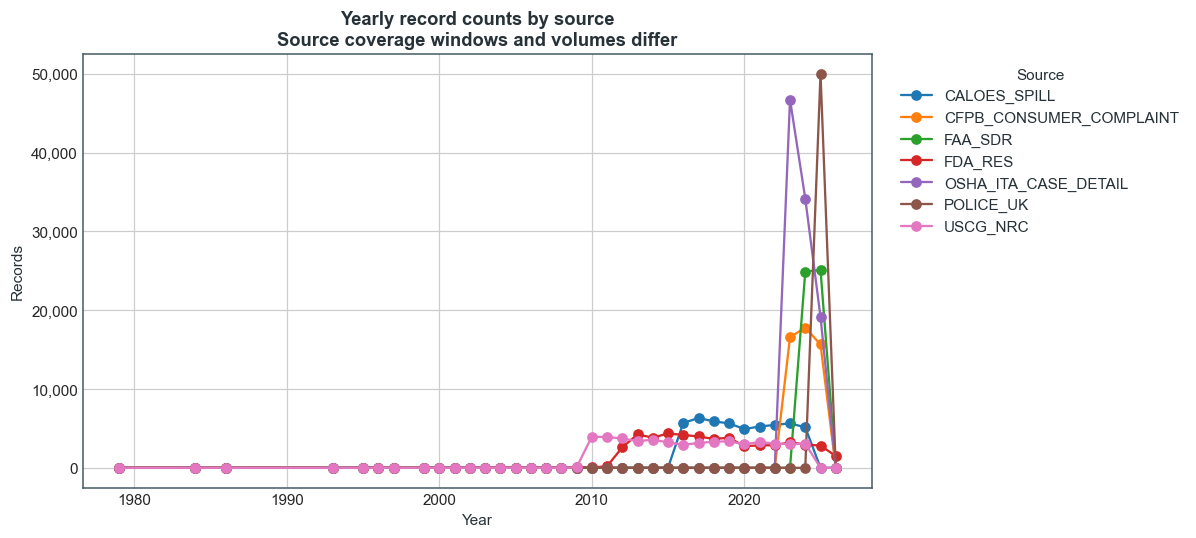

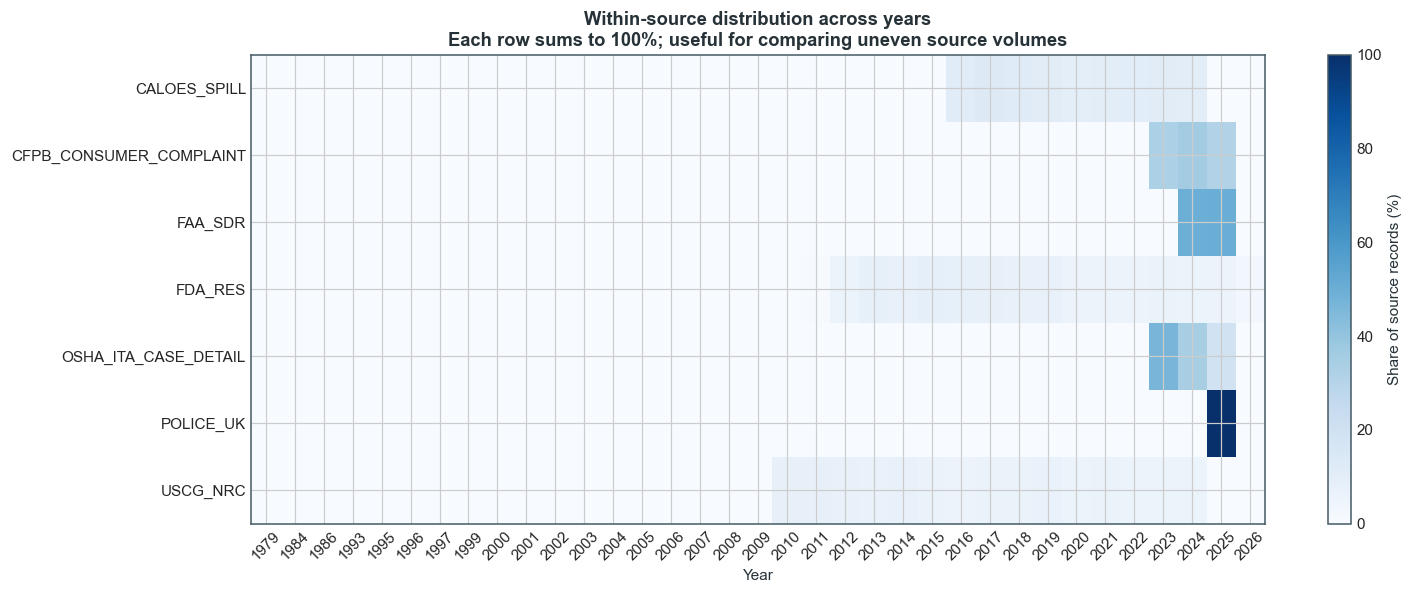

In [10]:
yearly = (
    parsed_dates.dropna(subset=["year"])
    .groupby(["year", "source"])
    .size()
    .unstack(fill_value=0)
)
ax = yearly.plot(figsize=(11, 5), marker="o", linewidth=1.5)
ax.set(
    xlabel="Year", ylabel="Records",
    title="Yearly record counts by source\nSource coverage windows and volumes differ",
)
ax.yaxis.set_major_formatter(count_formatter)
ax.legend(title="Source", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

yearly_source_share = yearly.div(yearly.sum(axis=0), axis=1).T * 100
fig, ax = plt.subplots(figsize=(14, 5.5))
image = ax.imshow(yearly_source_share, aspect="auto", cmap="Blues")
ax.set_xticks(range(len(yearly_source_share.columns)), yearly_source_share.columns, rotation=45)
ax.set_yticks(range(len(yearly_source_share.index)), yearly_source_share.index)
fig.colorbar(image, ax=ax, label="Share of source records (%)")
ax.set(
    xlabel="Year", ylabel="",
    title="Within-source distribution across years\nEach row sums to 100%; useful for comparing uneven source volumes",
)
plt.tight_layout()
plt.show()

## 6. Description length and repeated-title structure

Word count is computed with the dataset's normalized-whitespace convention:
one plus the number of spaces in each non-empty description. Linear and
logarithmic views are both shown because the distributions are right-skewed.
Log axes do not change the underlying counts; they expose the long tail.

,source,records,mean_chars,min_chars,max_chars,distinct_titles
0,OSHA_ITA_CASE_DETAIL,100000,824.7,414,4901,566
1,CALOES_SPILL,50000,751.9,301,4853,17544
2,CFPB_CONSUMER_COMPLAINT,50000,2205.5,616,33189,3
3,FAA_SDR,50000,822.5,275,10520,20169
4,FDA_RES,50000,5007.4,588,8868612,49658
5,POLICE_UK,50000,1070.2,995,1147,27092
6,USCG_NRC,50000,836.0,469,5795,53


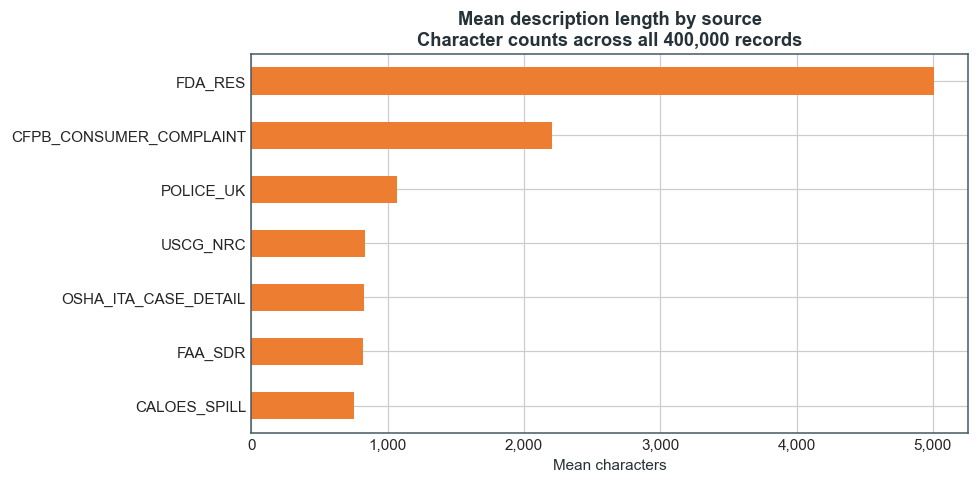

,word_count
count,400000.00
mean,208.74
std,2833.80
min,39.00
25%,101.00
50%,132.00
75%,170.00
90%,265.00
95%,366.00
99%,806.00


,records,mean,median,p10,p25,p75,p90,p99,maximum
case_type,,,,,,,,,
Occupational Health,50000,114.92,103.0,75.0,86.0,131.0,168.0,279.01,890
Asset and Reputation Damage/Loss,50000,125.76,105.0,73.0,84.0,142.0,200.0,409.00,1741
Environment,50000,119.55,110.0,76.0,90.0,137.0,174.0,278.00,734
Process Safety,50000,124.01,112.0,80.0,93.0,140.0,179.0,305.00,847
Occupational Safety,50000,128.97,118.0,87.0,99.0,147.0,182.0,296.00,789
Physical Security,50000,133.97,133.0,131.0,131.0,137.0,137.0,139.00,145
Operational Loss,50000,574.32,181.0,124.0,145.0,241.0,335.0,3513.17,985640
Information Security,50000,348.41,267.0,133.0,184.0,394.0,591.0,1824.00,5859


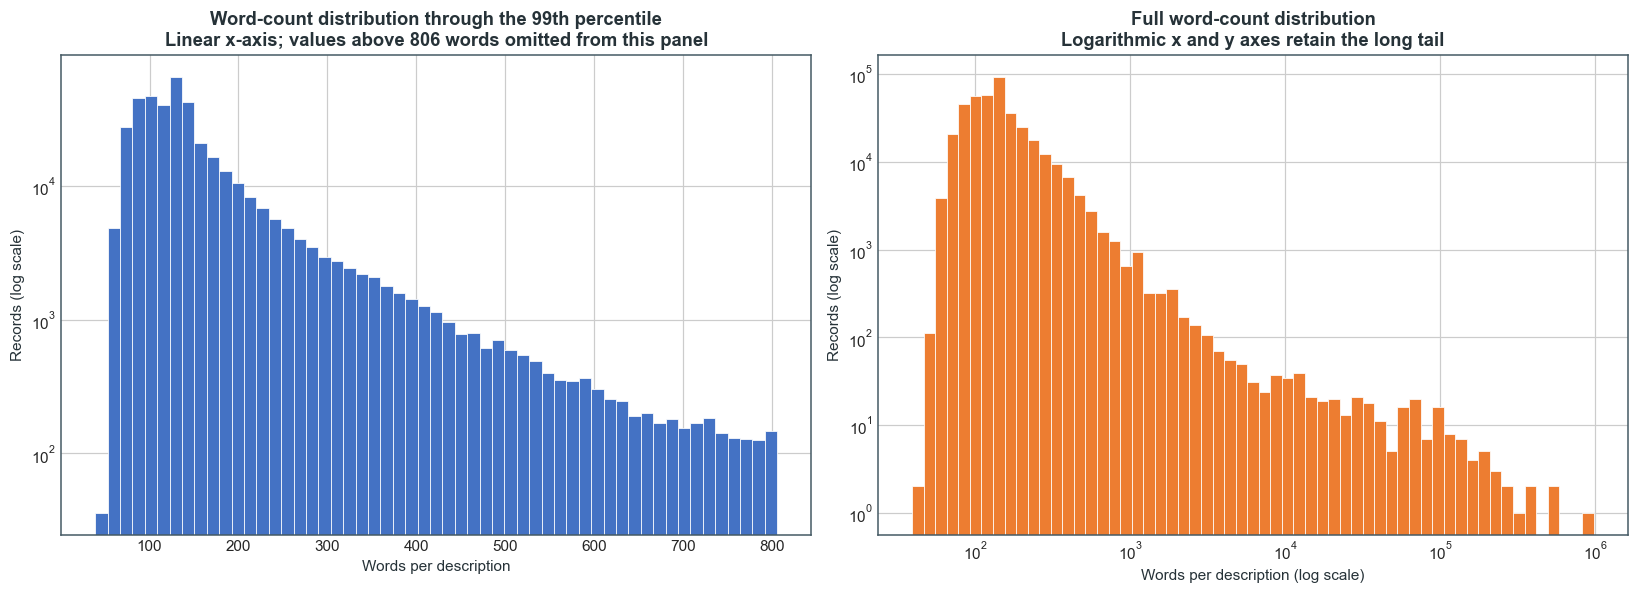

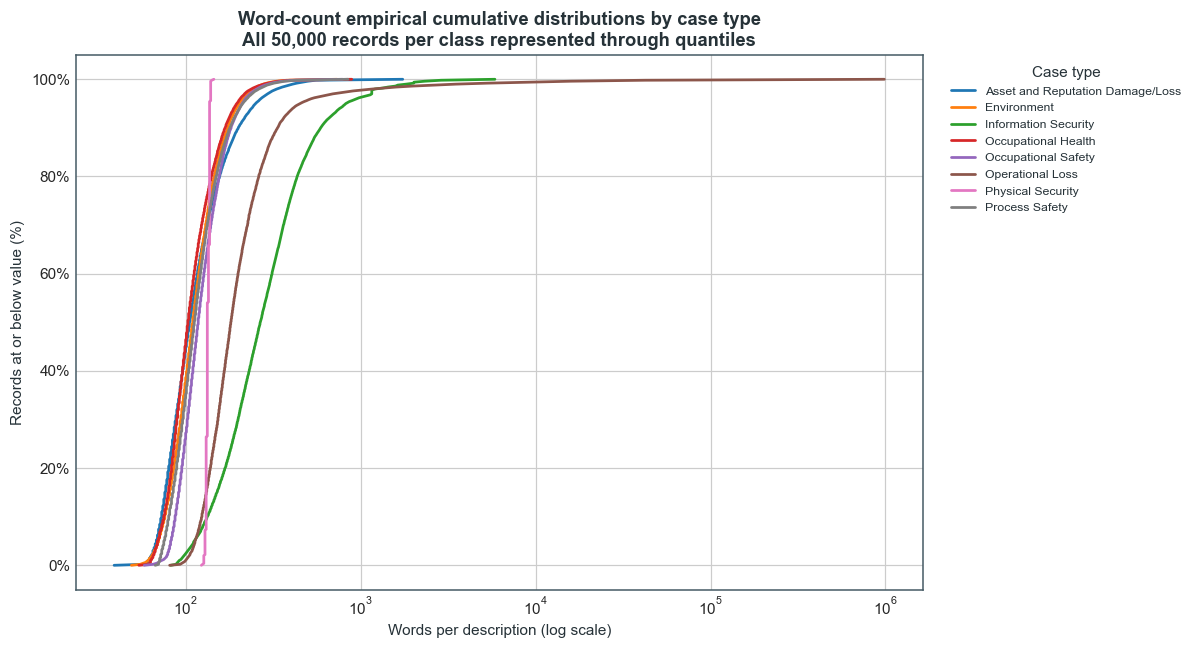

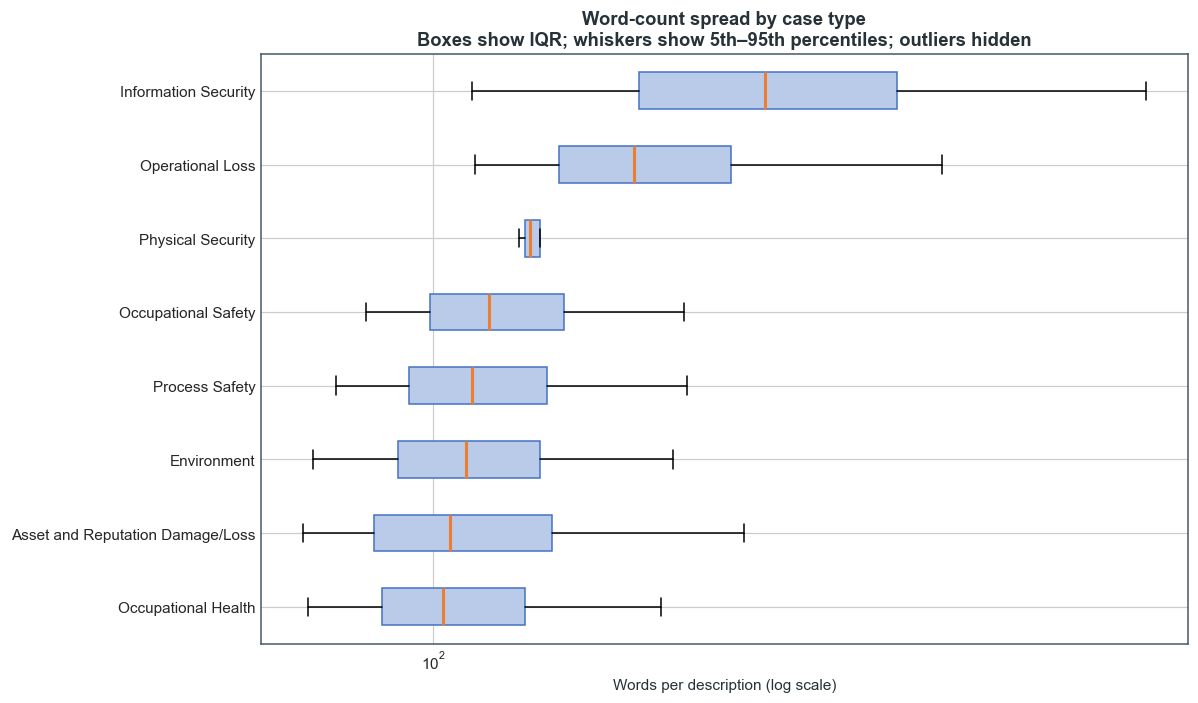

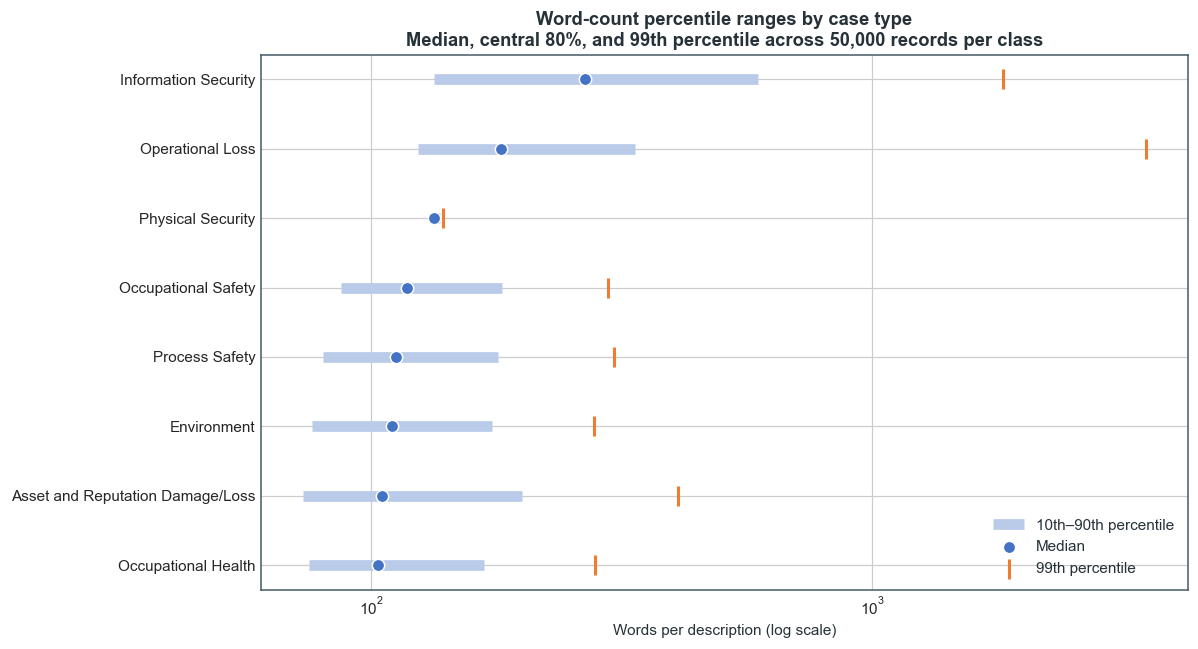

,records,median,p10,p90
country,,,,
United States of America,346990,126.0,81.0,283.0
United Kingdom,50181,133.0,131.0,137.0
China,196,166.0,140.0,314.5
India,178,168.0,132.7,228.3
Switzerland,188,175.0,119.0,407.6
Japan,133,184.0,148.4,303.0
Germany,273,189.0,128.0,355.4
Netherlands,201,198.0,127.0,760.0
France,142,208.0,131.0,362.9


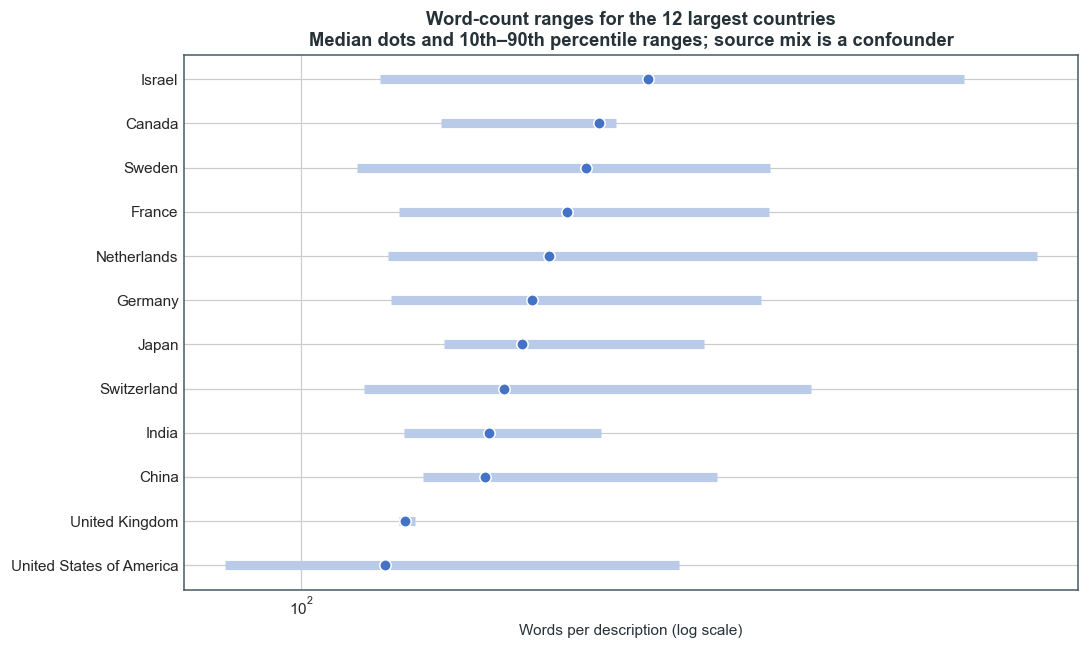

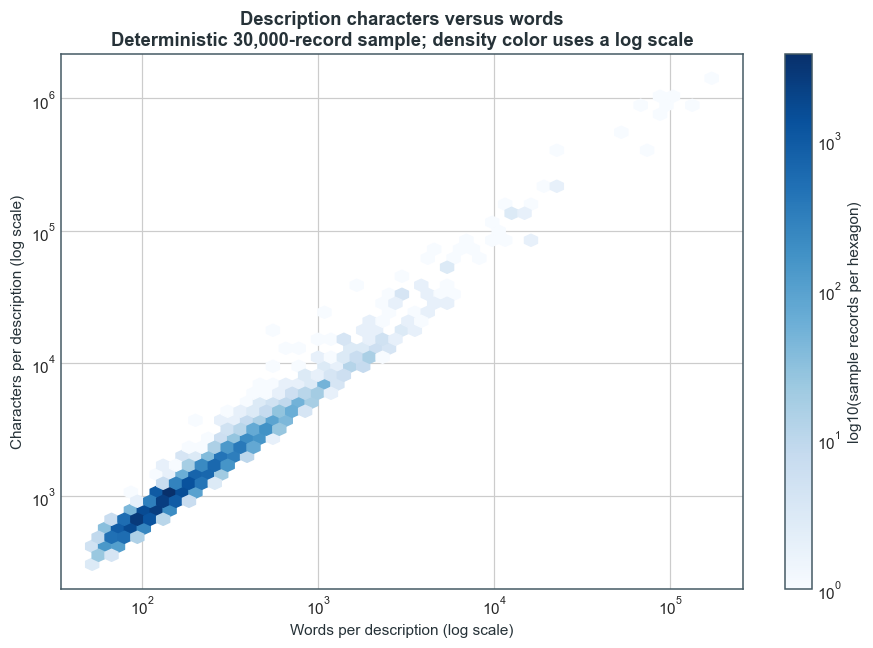

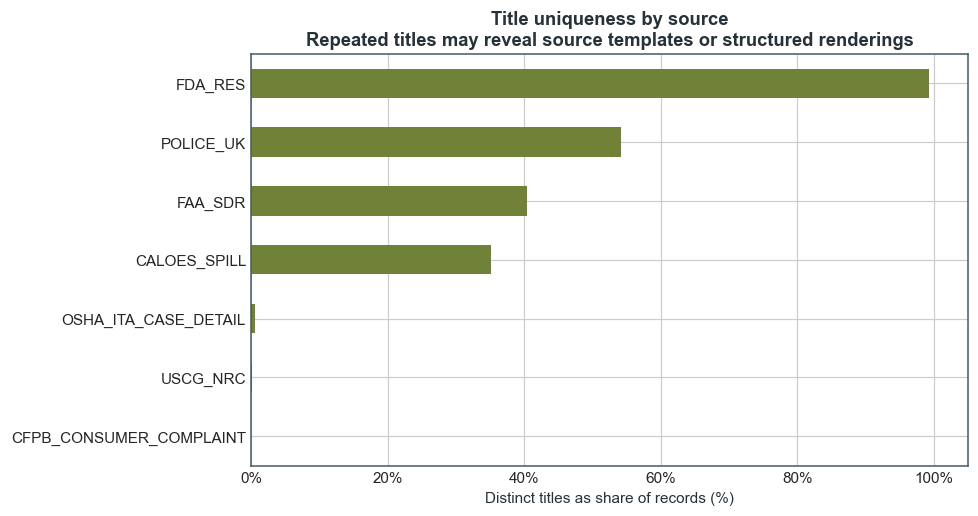

In [11]:
text_profile = pd.read_sql_query(
    '''
    SELECT source,
           COUNT(*) AS records,
           ROUND(AVG(LENGTH(description)), 1) AS mean_chars,
           MIN(LENGTH(description)) AS min_chars,
           MAX(LENGTH(description)) AS max_chars,
           COUNT(DISTINCT title) AS distinct_titles
    FROM incidents
    GROUP BY source
    ORDER BY records DESC
    ''',
    connection,
)
display(text_profile)

ax = text_profile.sort_values("mean_chars").plot.barh(
    x="source", y="mean_chars", legend=False, figsize=(9, 4.5), color="#ED7D31"
)
ax.set(
    xlabel="Mean characters", ylabel="",
    title="Mean description length by source\nCharacter counts across all 400,000 records",
)
ax.xaxis.set_major_formatter(count_formatter)
plt.tight_layout()
plt.show()

text_lengths = pd.read_sql_query(
    '''
    SELECT
        case_type, country, source,
        LENGTH(description) AS char_count,
        CASE
            WHEN TRIM(description) = '' THEN 0
            ELSE 1 + LENGTH(TRIM(description))
                 - LENGTH(REPLACE(TRIM(description), ' ', ''))
        END AS word_count
    FROM incidents
    ''',
    connection,
)
assert len(text_lengths) == 400_000
assert text_lengths["word_count"].min() >= 20

overall_word_summary = text_lengths["word_count"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999]
).to_frame("word_count")
word_summary_by_case = (
    text_lengths.groupby("case_type")["word_count"]
    .agg(
        records="size", mean="mean", median="median",
        p10=lambda values: values.quantile(0.10),
        p25=lambda values: values.quantile(0.25),
        p75=lambda values: values.quantile(0.75),
        p90=lambda values: values.quantile(0.90),
        p99=lambda values: values.quantile(0.99),
        maximum="max",
    )
    .sort_values("median")
)
display(overall_word_summary.round(2))
display(word_summary_by_case.round(2))

linear_limit = int(text_lengths["word_count"].quantile(0.99))
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].hist(
    text_lengths.loc[text_lengths["word_count"] <= linear_limit, "word_count"],
    bins=55, color=COLORS["blue"], edgecolor="white", linewidth=0.5,
)
axes[0].set_yscale("log")
axes[0].set(
    xlabel="Words per description", ylabel="Records (log scale)",
    title=f"Word-count distribution through the 99th percentile\nLinear x-axis; values above {linear_limit:,} words omitted from this panel",
)

minimum_words = max(1, int(text_lengths["word_count"].min()))
maximum_words = int(text_lengths["word_count"].max())
log_bins = np.geomspace(minimum_words, maximum_words + 1, 60)
axes[1].hist(
    text_lengths["word_count"], bins=log_bins, color=COLORS["orange"],
    edgecolor="white", linewidth=0.5,
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set(
    xlabel="Words per description (log scale)", ylabel="Records (log scale)",
    title="Full word-count distribution\nLogarithmic x and y axes retain the long tail",
)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 6))
quantile_grid = np.linspace(0, 1, 501)
for case_type, group in text_lengths.groupby("case_type"):
    quantile_values = group["word_count"].quantile(quantile_grid).to_numpy()
    ax.plot(quantile_values, quantile_grid * 100, label=case_type, linewidth=1.8)
ax.set_xscale("log")
ax.set(
    xlabel="Words per description (log scale)", ylabel="Records at or below value (%)",
    title="Word-count empirical cumulative distributions by case type\nAll 50,000 records per class represented through quantiles",
)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.legend(title="Case type", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

case_order = word_summary_by_case.index.tolist()
case_word_arrays = [
    text_lengths.loc[text_lengths["case_type"] == case_type, "word_count"].to_numpy()
    for case_type in case_order
]
fig, ax = plt.subplots(figsize=(11, 6.5))
boxplot = ax.boxplot(
    case_word_arrays, tick_labels=case_order, vert=False, showfliers=False,
    whis=(5, 95), patch_artist=True,
)
for box in boxplot["boxes"]:
    box.set(facecolor=COLORS["light_blue"], edgecolor=COLORS["blue"])
for median in boxplot["medians"]:
    median.set(color=COLORS["orange"], linewidth=2)
ax.set_xscale("log")
ax.set(
    xlabel="Words per description (log scale)", ylabel="",
    title="Word-count spread by case type\nBoxes show IQR; whiskers show 5th–95th percentiles; outliers hidden",
)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 6))
positions = np.arange(len(word_summary_by_case))
ax.hlines(
    positions, word_summary_by_case["p10"], word_summary_by_case["p90"],
    color=COLORS["light_blue"], linewidth=7, label="10th–90th percentile",
)
ax.scatter(
    word_summary_by_case["median"], positions, s=65, color=COLORS["blue"],
    edgecolor="white", zorder=3, label="Median",
)
ax.scatter(
    word_summary_by_case["p99"], positions, marker="|", s=180,
    color=COLORS["orange"], linewidth=2, label="99th percentile",
)
ax.set_xscale("log")
ax.set_yticks(positions, word_summary_by_case.index)
ax.set(
    xlabel="Words per description (log scale)", ylabel="",
    title="Word-count percentile ranges by case type\nMedian, central 80%, and 99th percentile across 50,000 records per class",
)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

top_text_countries = country_counts.head(12)["country"].tolist()
country_word_summary = (
    text_lengths[text_lengths["country"].isin(top_text_countries)]
    .groupby("country")["word_count"]
    .agg(
        records="size", median="median",
        p10=lambda values: values.quantile(0.10),
        p90=lambda values: values.quantile(0.90),
    )
    .sort_values("median")
)
display(country_word_summary.round(1))
fig, ax = plt.subplots(figsize=(10, 6))
positions = np.arange(len(country_word_summary))
ax.hlines(
    positions, country_word_summary["p10"], country_word_summary["p90"],
    color=COLORS["light_blue"], linewidth=6,
)
ax.scatter(
    country_word_summary["median"], positions, s=55, color=COLORS["blue"],
    edgecolor="white", zorder=3,
)
ax.set_xscale("log")
ax.set_yticks(positions, country_word_summary.index)
ax.set(
    xlabel="Words per description (log scale)", ylabel="",
    title="Word-count ranges for the 12 largest countries\nMedian dots and 10th–90th percentile ranges; source mix is a confounder",
)
plt.tight_layout()
plt.show()

scatter_sample = text_lengths.sample(n=30_000, random_state=42)
fig, ax = plt.subplots(figsize=(8.5, 6))
hexbin = ax.hexbin(
    scatter_sample["word_count"], scatter_sample["char_count"],
    gridsize=48, xscale="log", yscale="log", bins="log",
    mincnt=1, cmap="Blues",
)
fig.colorbar(hexbin, ax=ax, label="log10(sample records per hexagon)")
ax.set(
    xlabel="Words per description (log scale)",
    ylabel="Characters per description (log scale)",
    title="Description characters versus words\nDeterministic 30,000-record sample; density color uses a log scale",
)
plt.tight_layout()
plt.show()

text_profile["unique_title_pct"] = (
    100 * text_profile["distinct_titles"] / text_profile["records"]
)
ax = text_profile.sort_values("unique_title_pct").plot.barh(
    x="source", y="unique_title_pct", legend=False, figsize=(9, 4.8),
    color=COLORS["olive"],
)
ax.set(
    xlabel="Distinct titles as share of records (%)", ylabel="",
    title="Title uniqueness by source\nRepeated titles may reveal source templates or structured renderings",
)
ax.set_xlim(0, 105)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
plt.tight_layout()
plt.show()

## 7. Train/validation/test balance

dataset_split,test,train,validation
case_type,,,
Asset and Reputation Damage/Loss,5091,39979,4930
Environment,5114,39860,5026
Information Security,4998,39954,5048
Occupational Health,4872,40097,5031
Occupational Safety,5096,39821,5083
Operational Loss,5047,39909,5044
Physical Security,4993,40019,4988
Process Safety,4936,39959,5105


dataset_split,test,train,validation
case_type,,,
Asset and Reputation Damage/Loss,10.18,79.96,9.86
Environment,10.23,79.72,10.05
Information Security,10.00,79.91,10.10
Occupational Health,9.74,80.19,10.06
Occupational Safety,10.19,79.64,10.17
Operational Loss,10.09,79.82,10.09
Physical Security,9.99,80.04,9.98
Process Safety,9.87,79.92,10.21


Delta from target (pp),train,validation,test
case_type,,,
Asset and Reputation Damage/Loss,-0.04,-0.14,0.18
Environment,-0.28,0.05,0.23
Information Security,-0.09,0.10,-0.00
Occupational Health,0.19,0.06,-0.26
Occupational Safety,-0.36,0.17,0.19
Operational Loss,-0.18,0.09,0.09
Physical Security,0.04,-0.02,-0.01
Process Safety,-0.08,0.21,-0.13


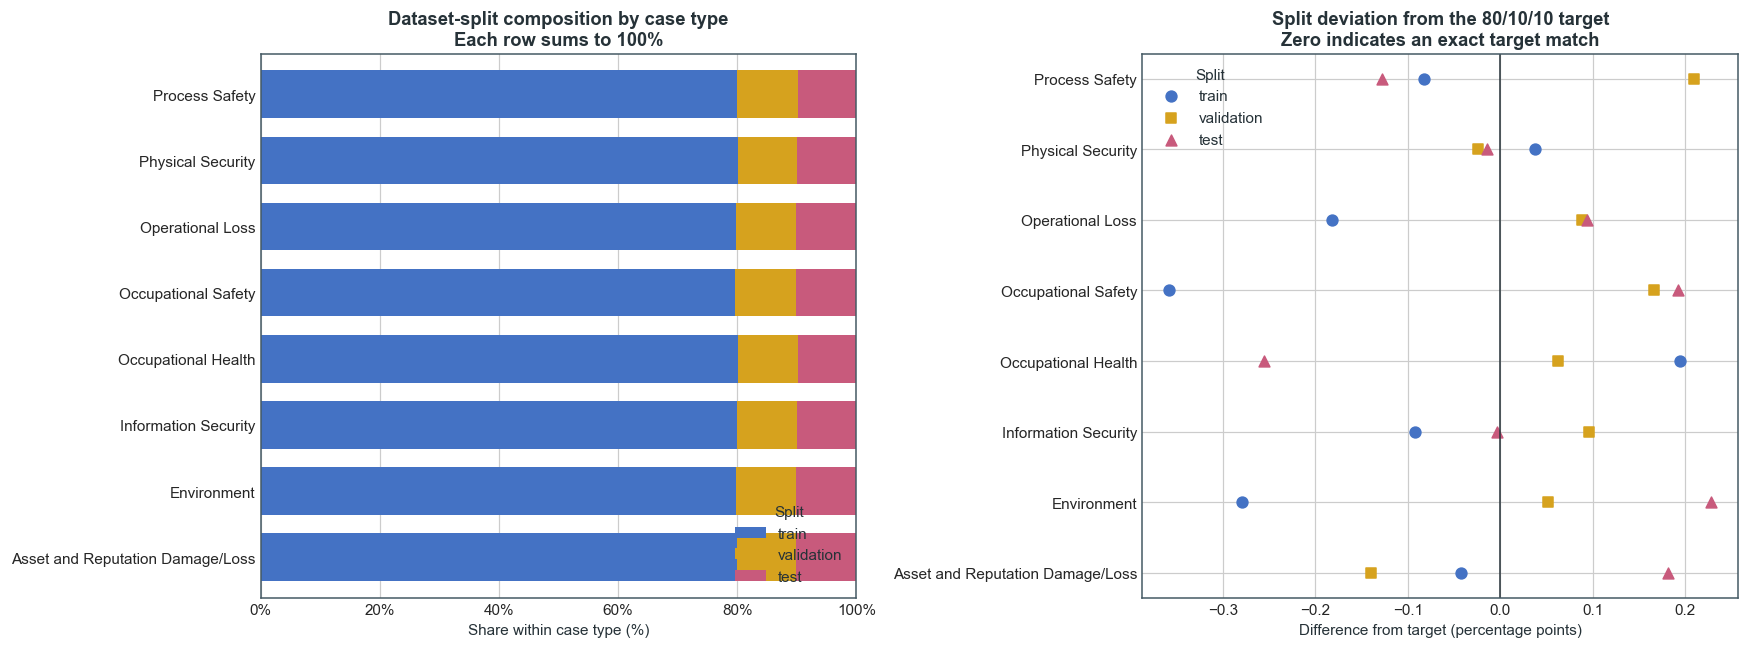

In [12]:
splits = pd.read_sql_query(
    '''
    SELECT case_type, dataset_split, COUNT(*) AS records
    FROM incidents
    GROUP BY case_type, dataset_split
    ''',
    connection,
)
split_pivot = splits.pivot(index="case_type", columns="dataset_split", values="records")
split_pct = split_pivot.div(split_pivot.sum(axis=1), axis=0) * 100
display(split_pivot)
display(split_pct.round(2))

target = pd.Series({"train": 80.0, "validation": 10.0, "test": 10.0})
split_delta = split_pct[target.index] - target
display(split_delta.round(2).rename_axis(columns="Delta from target (pp)"))
assert np.allclose(split_pct.sum(axis=1), 100.0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
split_pct[target.index].plot.barh(
    stacked=True, ax=axes[0], width=0.72,
    color=[COLORS["blue"], COLORS["gold"], COLORS["pink"]],
)
axes[0].set(
    xlabel="Share within case type (%)", ylabel="",
    title="Dataset-split composition by case type\nEach row sums to 100%",
)
axes[0].set_xlim(0, 100)
axes[0].xaxis.set_major_formatter(PercentFormatter(xmax=100))
axes[0].legend(title="Split", loc="lower right")

delta_long = split_delta.stack().rename("delta_pp").reset_index()
for split_name, color, marker in [
    ("train", COLORS["blue"], "o"),
    ("validation", COLORS["gold"], "s"),
    ("test", COLORS["pink"], "^"),
]:
    subset = delta_long[delta_long["dataset_split"] == split_name]
    positions = [split_pct.index.get_loc(value) for value in subset["case_type"]]
    axes[1].scatter(
        subset["delta_pp"], positions, label=split_name, color=color, marker=marker, s=50
    )
axes[1].axvline(0, color=COLORS["ink"], linewidth=1)
axes[1].set_yticks(range(len(split_pct.index)), split_pct.index)
axes[1].set(
    xlabel="Difference from target (percentage points)", ylabel="",
    title="Split deviation from the 80/10/10 target\nZero indicates an exact target match",
)
axes[1].legend(title="Split")
plt.tight_layout()
plt.show()

## 8. Bounded full-text-search example

In [13]:
query = "fire OR explosion"
fts_results = pd.read_sql_query(
    '''
    SELECT i.case_no, i.case_type, i.source, i.title,
           snippet(incidents_fts, 2, '[', ']', ' … ', 18) AS match
    FROM incidents_fts
    JOIN incidents AS i ON i.rowid = incidents_fts.rowid
    WHERE incidents_fts MATCH ?
    LIMIT 12
    ''',
    connection,
    params=(query,),
)
display(fts_results)

,case_no,case_type,source,title,match
0,USCG-NRC:1306311,Process Safety,USCG_NRC,Fixed — Operator Error,"… The standardized hazard type is “[Fire]/[Explosion]”.\n\nReported release, affected media, consequences and response actions: The cal..."
1,CALOES:17-5725,Environment,CALOES_SPILL,"Vehicle Fluids - Oil, Fuel spill notification — Collision","… directly into a waterway, FD is handling the containment, unknown who is performing clean up\n\n- FD = [Fire] Department"
2,CALOES:23-0508,Environment,CALOES_SPILL,Gasoline spill notification — Collision,… The [Fire] Department was on the scene but there was no remedial actions. The gasoline is still on …
3,CALOES:23-4354,Environment,CALOES_SPILL,Transformer Oil (Unknown PCBs) spill notification — Other — Fire,… The source categorizes the reported cause or event as Other; [Fire].\n\nReported environmental impact and response: Due to …
4,USCG-NRC:1089836,Process Safety,USCG_NRC,Fixed — Equipment Failure,"… The standardized hazard type is “[Fire]/[Explosion]”.\n\nReported release, affected media, consequences and response actions: Update ..."
5,USCG-NRC:1268844,Process Safety,USCG_NRC,Pipeline process-safety notification,"… The standardized hazard type is “[Fire]/[Explosion]”.\n\nReported release, affected media, consequences and response actions: ///// 4..."
6,OSHA-ITA:2023:469509,Occupational Safety,OSHA_ITA_CASE_DETAIL,"Overexertion involving outside sources: Traumatic injuries to muscles, tendons, ligaments, joints, etc",… The standardized hazard type is “[Fire]/[Explosion]”.\n\nReported incident circumstances and effects: Pulled Lower Back. When associa...
7,USCG-NRC:1200028,Process Safety,USCG_NRC,Storage Tank — Dumping,"… The standardized hazard type is “[Fire]/[Explosion]”.\n\nReported release, affected media, consequences and response actions: What ap..."
8,USCG-NRC:955441,Process Safety,USCG_NRC,Fixed process-safety notification,"… The standardized hazard type is “[Fire]/[Explosion]”.\n\nReported release, affected media, consequences and response actions: Caller ..."
9,OSHA-ITA:2024:1411092,Occupational Safety,OSHA_ITA_CASE_DETAIL,"Contact with animals: Effects of poison, toxic, or allergenic exposure",… The standardized hazard type is “[Fire]/[Explosion]”.\n\nReported incident circumstances and effects: The Employee step on a hill …


## Takeaways and cautions

1. The corpus is exactly balanced by design; source and case type are strongly
   coupled, so a random split can reward source-style recognition.
2. Descriptions are authentic reports or fixed source-field renderings, but
   complaint and initial-report sources are not necessarily independently verified.
3. Unknown severity is informative missingness, not a low-severity label.
4. Date coverage and precision differ materially by source.
5. Geographic comparisons are dominated by source scope.
6. Description word counts are strongly right-skewed—especially for Operational
   Loss—so medians, percentile ranges, and log-scale views are more informative
   than means alone.
7. Before performance claims, create a human-reviewed, source-stratified gold
   set and test source-held-out as well as random-split generalisation.

In [14]:
connection.close()
print("Closed the read-only SQLite connection.")

Closed the read-only SQLite connection.
